In [2]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aditisaxena20/superstore-sales-dataset")

print("Path to dataset files:", path)


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


100%|██████████| 2.20M/2.20M [00:01<00:00, 1.69MB/s]

Extracting files...
Path to dataset files: C:\Users\Han\.cache\kagglehub\datasets\aditisaxena20\superstore-sales-dataset\versions\1


In [6]:
import pandas as pd

# Read the CSV file
df = pd.read_csv(path + '\\SuperStore_Orders.csv', encoding='latin-1')

# Display the first few rows of the dataframe
print(df.head())

          order_id  order_date   ship_date       ship_mode    customer_name  \
0     AG-2011-2040  01-01-2011  06-01-2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883  01-01-2011  08-01-2011  Standard Class      Joseph Holt   
2     HU-2011-1220  01-01-2011  05-01-2011    Second Class    Annie Thurman   
3  IT-2011-3647632  01-01-2011  05-01-2011    Second Class     Eugene Moren   
4    IN-2011-47883  01-01-2011  08-01-2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage      


Key Statistics:
Total Sales: $12,642,905.00
Total Profit: $1,469,034.82
Average Discount: 14.29%
Most Common Ship Mode: Standard Class


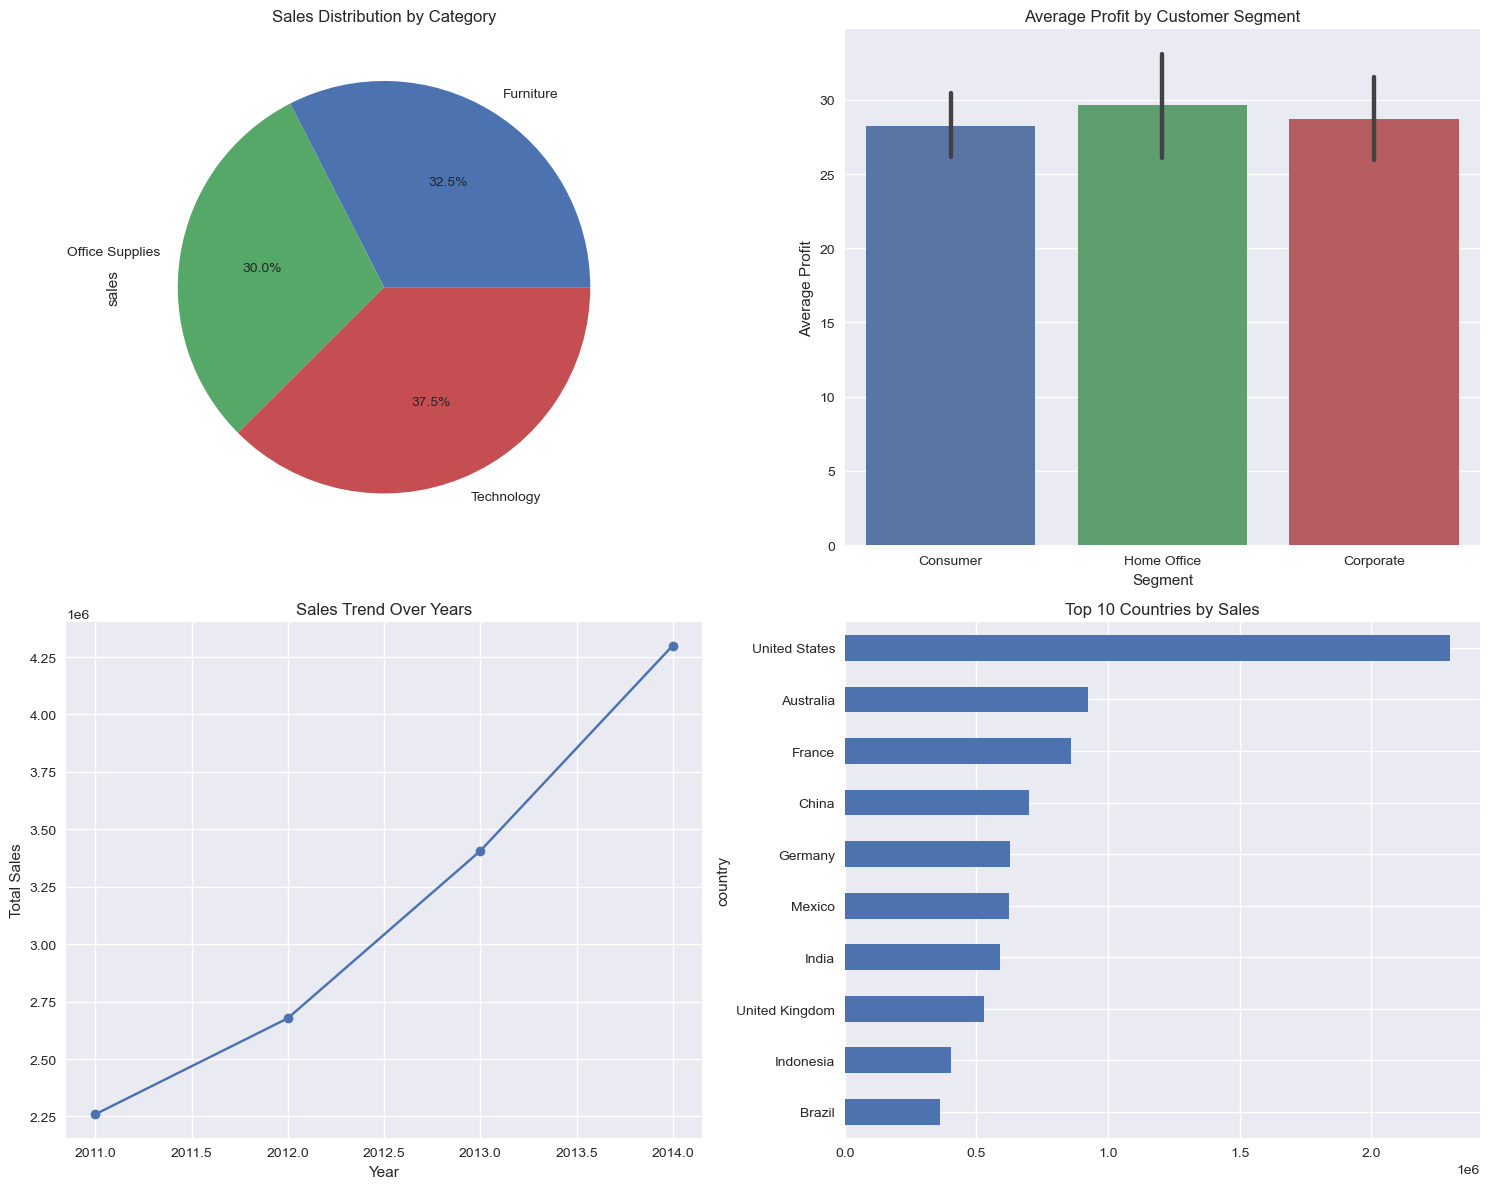

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for better visualization
plt.style.use('seaborn-v0_8')  # or you can use 'seaborn-darkgrid'
# Sales is already in float format, no conversion needed


fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sales by Category
df.groupby('category')['sales'].sum().astype(float).plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0,0], title='Sales Distribution by Category')

# 2. Average Profit by Segment
sns.barplot(data=df, x='segment', y='profit', ax=axes[0,1])
axes[0,1].set_title('Average Profit by Customer Segment')
axes[0,1].set_xlabel('Segment')
axes[0,1].set_ylabel('Average Profit')

# 3. Sales Trend Over Years
yearly_sales = df.groupby('year')['sales'].sum().astype(float)
yearly_sales.plot(kind='line', marker='o', ax=axes[1,0])
axes[1,0].set_title('Sales Trend Over Years')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Total Sales')

# 4. Top 10 Countries by Sales
top_countries = df.groupby('country')['sales'].sum().astype(float).sort_values(ascending=True)[-10:]
top_countries.plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('Top 10 Countries by Sales')

plt.tight_layout()

# Print key statistics
print("\nKey Statistics:")
print(f"Total Sales: ${df['sales'].astype(float).sum():,.2f}")
print(f"Total Profit: ${df['profit'].sum():,.2f}")
print(f"Average Discount: {df['discount'].mean():.2%}")
print(f"Most Common Ship Mode: {df['ship_mode'].mode()[0]}")